In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [26]:
# Load Wine Quality Dataset

df = pd.read_csv(
    "dataset/winequality-red.csv",
    sep=";"
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset loaded successfully!
Dataset Shape: (1599, 12)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

First 5 Rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [27]:
# Statistical Summary

print("Statistical Summary:")
display(df.describe().T)

print("\nData Types:")
print(df.dtypes)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000



Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [28]:
# Data Quality Check

print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Variable Distribution:")
print(df["quality"].value_counts().sort_index())

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 240

Target Variable Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


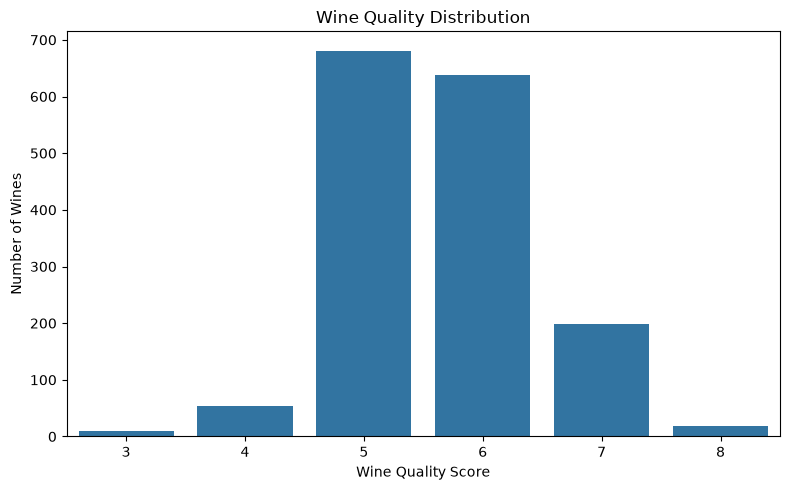

In [29]:
# Wine Quality Distribution

quality_counts = df["quality"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=quality_counts.index,
    y=quality_counts.values
)

plt.title("Wine Quality Distribution")
plt.xlabel("Wine Quality Score")
plt.ylabel("Number of Wines")

plt.tight_layout()
plt.show()

In [30]:
# Correlation with Wine Quality

correlation_with_quality = (
    df.corr(numeric_only=True)["quality"]
    .sort_values(ascending=False)
)

print("Correlation with Quality:")
display(correlation_with_quality)

Correlation with Quality:


quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

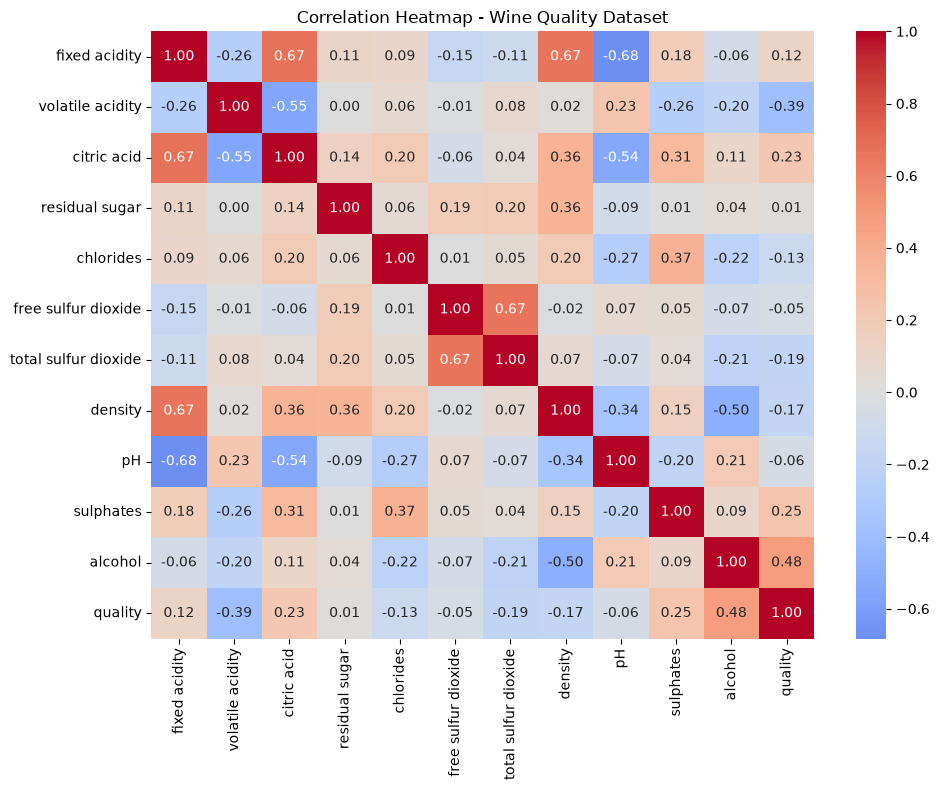

In [31]:
# Correlation Heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap - Wine Quality Dataset")
plt.tight_layout()
plt.show()

In [32]:
# Separate Features and Target

X = df.drop("quality", axis=1)
y = df["quality"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(sorted(y.unique()))

Features Shape: (1599, 11)
Target Shape: (1599,)

Feature Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target Classes:
[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [33]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed!")
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Train-Test Split Completed!
Training Features Shape: (1279, 11)
Testing Features Shape: (320, 11)
Training Target Shape: (1279,)
Testing Target Shape: (320,)


In [34]:
# Feature Scaling

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Feature scaling completed!
Scaled Training Shape: (1279, 11)
Scaled Testing Shape: (320, 11)


In [35]:
# Logistic Regression Model

wine_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model
wine_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = wine_model.predict(X_test_scaled)

print("Wine Quality Prediction Model trained successfully!")
print("Number of predictions:", len(y_pred))

Wine Quality Prediction Model trained successfully!
Number of predictions: 320


In [36]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Wine Quality Prediction - Model Evaluation")
print("-------------------------------------------")
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Wine Quality Prediction - Model Evaluation
-------------------------------------------
Accuracy: 0.5906

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



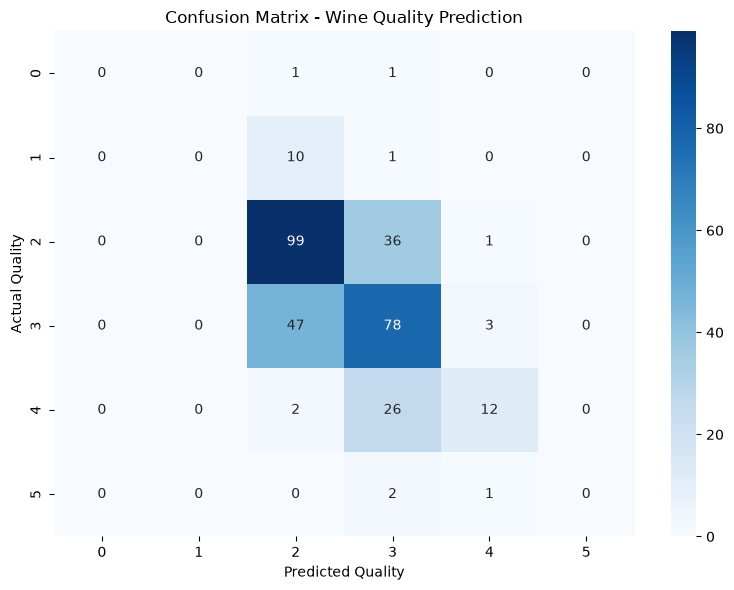

In [37]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Wine Quality Prediction")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")

plt.tight_layout()
plt.show()

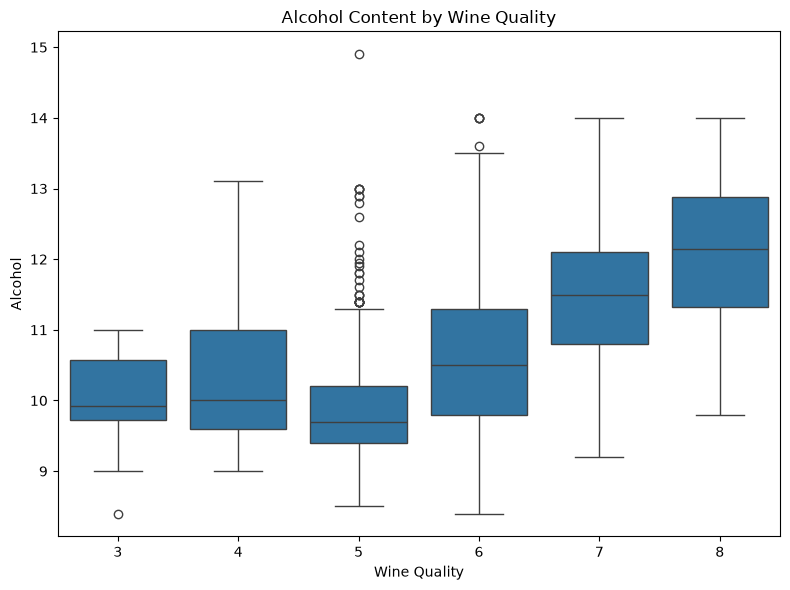

In [38]:
# Alcohol vs Wine Quality

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="quality",
    y="alcohol"
)

plt.title("Alcohol Content by Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")

plt.tight_layout()
plt.show()

In [39]:
# Feature Engineering: Convert wine quality scores into 3 classes

def quality_category(score):
    if score <= 5:
        return "Low"
    elif score <= 6:
        return "Medium"
    else:
        return "High"

df["quality_category"] = df["quality"].apply(quality_category)

print("Quality categories created successfully!")
print("\nQuality Category Distribution:")
print(df["quality_category"].value_counts())

display(df[["quality", "quality_category"]].head(10))

Quality categories created successfully!

Quality Category Distribution:
quality_category
Low       744
Medium    638
High      217
Name: count, dtype: int64


,quality,quality_category
0,5,Low
1,5,Low
2,5,Low
3,6,Medium
4,5,Low
5,5,Low
6,5,Low
7,7,High
8,7,High
9,5,Low


In [40]:
# Prepare features and 3-class target for machine learning

X = df.drop(["quality", "quality_category"], axis=1)
y = df["quality_category"]

print("Features shape:", X.shape)
print("Target classes:")
print(y.value_counts())

Features shape: (1599, 11)
Target classes:
quality_category
Low       744
Medium    638
High      217
Name: count, dtype: int64


In [41]:
# Stratified Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (1279, 11)
Testing data shape: (320, 11)

Training class distribution:
quality_category
Low       0.465207
Medium    0.398749
High      0.136044
Name: proportion, dtype: float64

Testing class distribution:
quality_category
Low       0.465625
Medium    0.400000
High      0.134375
Name: proportion, dtype: float64


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Create the three required classifiers

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

sgd_model = SGDClassifier(
    random_state=42
)

svc_model = SVC(
    random_state=42
)

# Train all three models

rf_model.fit(X_train, y_train)
sgd_model.fit(X_train, y_train)
svc_model.fit(X_train, y_train)

# Predictions

rf_pred = rf_model.predict(X_test)
sgd_pred = sgd_model.predict(X_test)
svc_pred = svc_model.predict(X_test)

print("All three models trained successfully!")

All three models trained successfully!


In [43]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy

rf_accuracy = accuracy_score(y_test, rf_pred)
sgd_accuracy = accuracy_score(y_test, sgd_pred)
svc_accuracy = accuracy_score(y_test, svc_pred)

print("===== RANDOM FOREST =====")
print(f"Accuracy: {rf_accuracy:.4f}")
print(classification_report(y_test, rf_pred, zero_division=0))

print("\n===== SGD CLASSIFIER =====")
print(f"Accuracy: {sgd_accuracy:.4f}")
print(classification_report(y_test, sgd_pred, zero_division=0))

print("\n===== SUPPORT VECTOR CLASSIFIER =====")
print(f"Accuracy: {svc_accuracy:.4f}")
print(classification_report(y_test, svc_pred, zero_division=0))

===== RANDOM FOREST =====
Accuracy: 0.7562
              precision    recall  f1-score   support

        High       0.69      0.56      0.62        43
         Low       0.80      0.85      0.82       149
      Medium       0.72      0.72      0.72       128

    accuracy                           0.76       320
   macro avg       0.74      0.71      0.72       320
weighted avg       0.75      0.76      0.75       320


===== SGD CLASSIFIER =====
Accuracy: 0.5469
              precision    recall  f1-score   support

        High       0.35      0.65      0.46        43
         Low       0.61      0.89      0.72       149
      Medium       0.64      0.11      0.19       128

    accuracy                           0.55       320
   macro avg       0.53      0.55      0.46       320
weighted avg       0.59      0.55      0.47       320


===== SUPPORT VECTOR CLASSIFIER =====
Accuracy: 0.5375
              precision    recall  f1-score   support

        High       1.00      0.02      

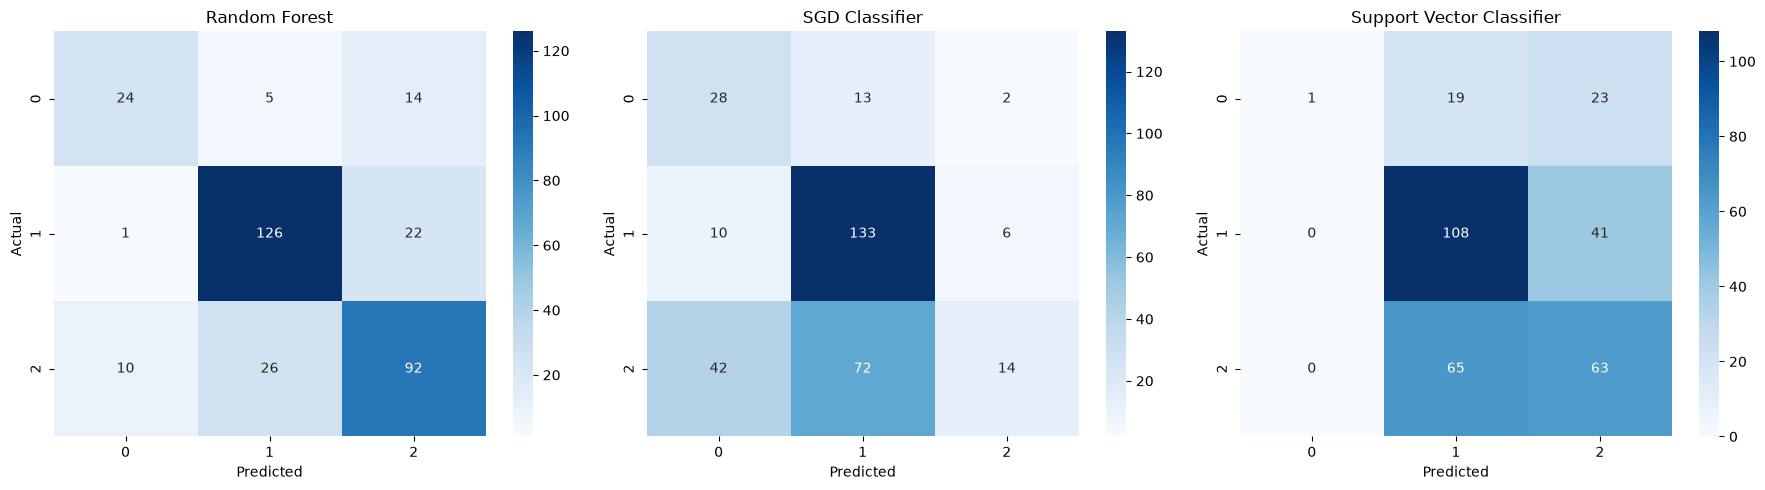

In [44]:
from sklearn.metrics import confusion_matrix

# Confusion Matrices for all three models

rf_cm = confusion_matrix(y_test, rf_pred)
sgd_cm = confusion_matrix(y_test, sgd_pred)
svc_cm = confusion_matrix(y_test, svc_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("SGD Classifier")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2]
)
axes[2].set_title("Support Vector Classifier")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

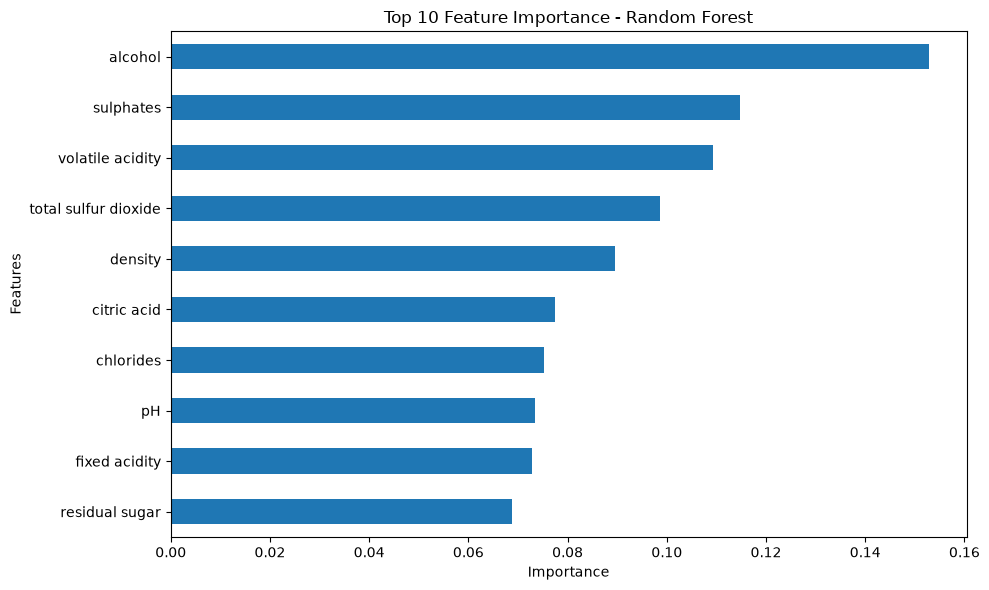

In [45]:
# Random Forest Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [46]:
# Model Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "Support Vector Classifier"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,Accuracy
0,Random Forest,0.756250
1,SGD Classifier,0.546875
2,Support Vector Classifier,0.537500


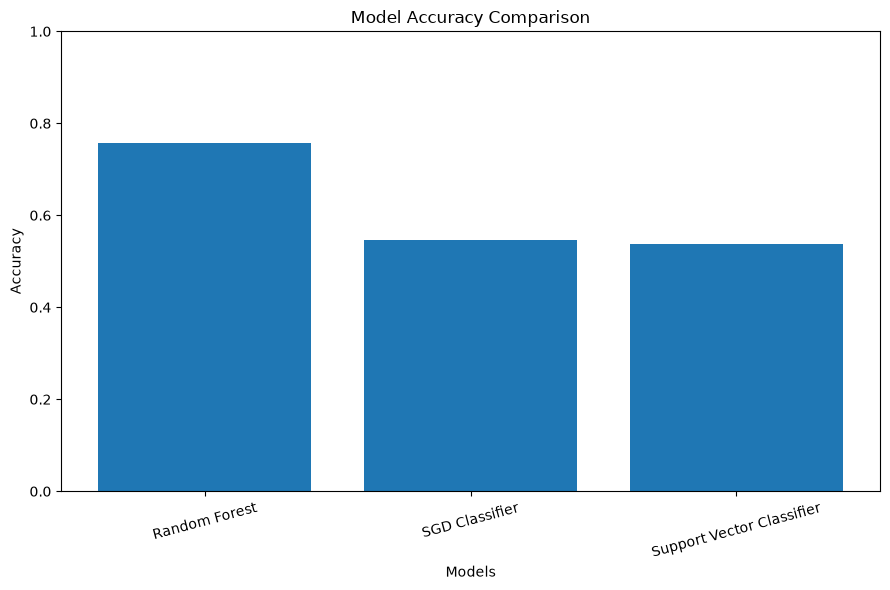

In [47]:
# Model Accuracy Comparison

plt.figure(figsize=(9, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [48]:
# Identify the best performing model

best_model = model_comparison.iloc[0]

print("Best Model:", best_model["Model"])
print(f"Best Accuracy: {best_model['Accuracy']:.4f}")

Best Model: Random Forest
Best Accuracy: 0.7562


## Conclusion

In this project, a machine learning classification pipeline was developed to predict wine quality using the physicochemical properties of red wine.

The dataset was explored using descriptive statistics, missing-value checks, duplicate checks, quality distribution analysis, correlation analysis, and visualizations. The original wine quality scores were converted into three categories: Low, Medium, and High, to make the prediction problem suitable for classification.

The dataset was divided into training and testing sets using an 80:20 stratified split to preserve the class distribution.

Three classification models were trained and evaluated:
- Random Forest Classifier
- SGD Classifier
- Support Vector Classifier (SVC)

The models were evaluated using accuracy, classification reports, and confusion matrices. Random Forest achieved the highest accuracy of 75.62% among the three models.

Therefore, Random Forest is the most suitable model for deployment among the tested models because it provided the best classification accuracy and also provides feature importance information that helps understand which physicochemical properties contribute most to wine quality prediction.

This project demonstrates how machine learning can be applied to predict wine quality and support data-driven analysis of wine characteristics.